In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display

full_data = pd.read_csv(r"../../data/processed/data_final_shift.csv",
                        index_col="Date", parse_dates=True).sort_index()

def check_multicollinearity(data, target_col=None):
    """
    데이터프레임을 입력받아 상관계수 히트맵과 VIF 수치를 출력하는 함수
    
    :param data: 분석할 pandas DataFrame
    :param target_col: 제외할 타겟 변수명 (문자열, 생략 가능)
    :return: VIF 결과가 담긴 DataFrame
    """
    print("=" * 50)
    print("🚀 다중공선성(Multicollinearity) 분석 시작")
    print("=" * 50)
    
    # 1. 데이터 전처리 (타겟 제외 -> 숫자형 추출 -> 결측치/무한대 제거)
    if target_col and target_col in data.columns:
        df = data.drop(columns=[target_col])
    else:
        df = data.copy()
        
    X = (df.select_dtypes(include=[np.number])
           .replace([np.inf, -np.inf], np.nan)
           .dropna())
           
    print(f"✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): {X.shape}\n")
    
    # 2. 피어슨 상관계수 히트맵
    plt.figure(figsize=(16, 12))
    corr_matrix = X.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Feature Correlation Heatmap", fontsize=16)
    plt.show()
    
    # 3. 분산팽창지수 (VIF) 계산
    X_vif = add_constant(X)
    vif_df = pd.DataFrame({
        "Feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).query("Feature != 'const'").sort_values(by="VIF", ascending=False).reset_index(drop=True)
    
    pd.options.display.float_format = '{:.4f}'.format
    
    print("\n[ 📊 변수별 VIF 결과 ]")
    display(vif_df)
    
    # 4. 위험 변수 목록 출력
    high_vif = vif_df[vif_df["VIF"] >= 10]['Feature'].tolist()
    print("\n🚨 VIF 10 이상인 위험 변수 목록:")
    if high_vif:
        print(high_vif)
    else:
        print("위험 수준의 변수가 없습니다. (모든 VIF 10 미만)")

## 전체 데이터에서 VIF 확인 (full_data)

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 42)



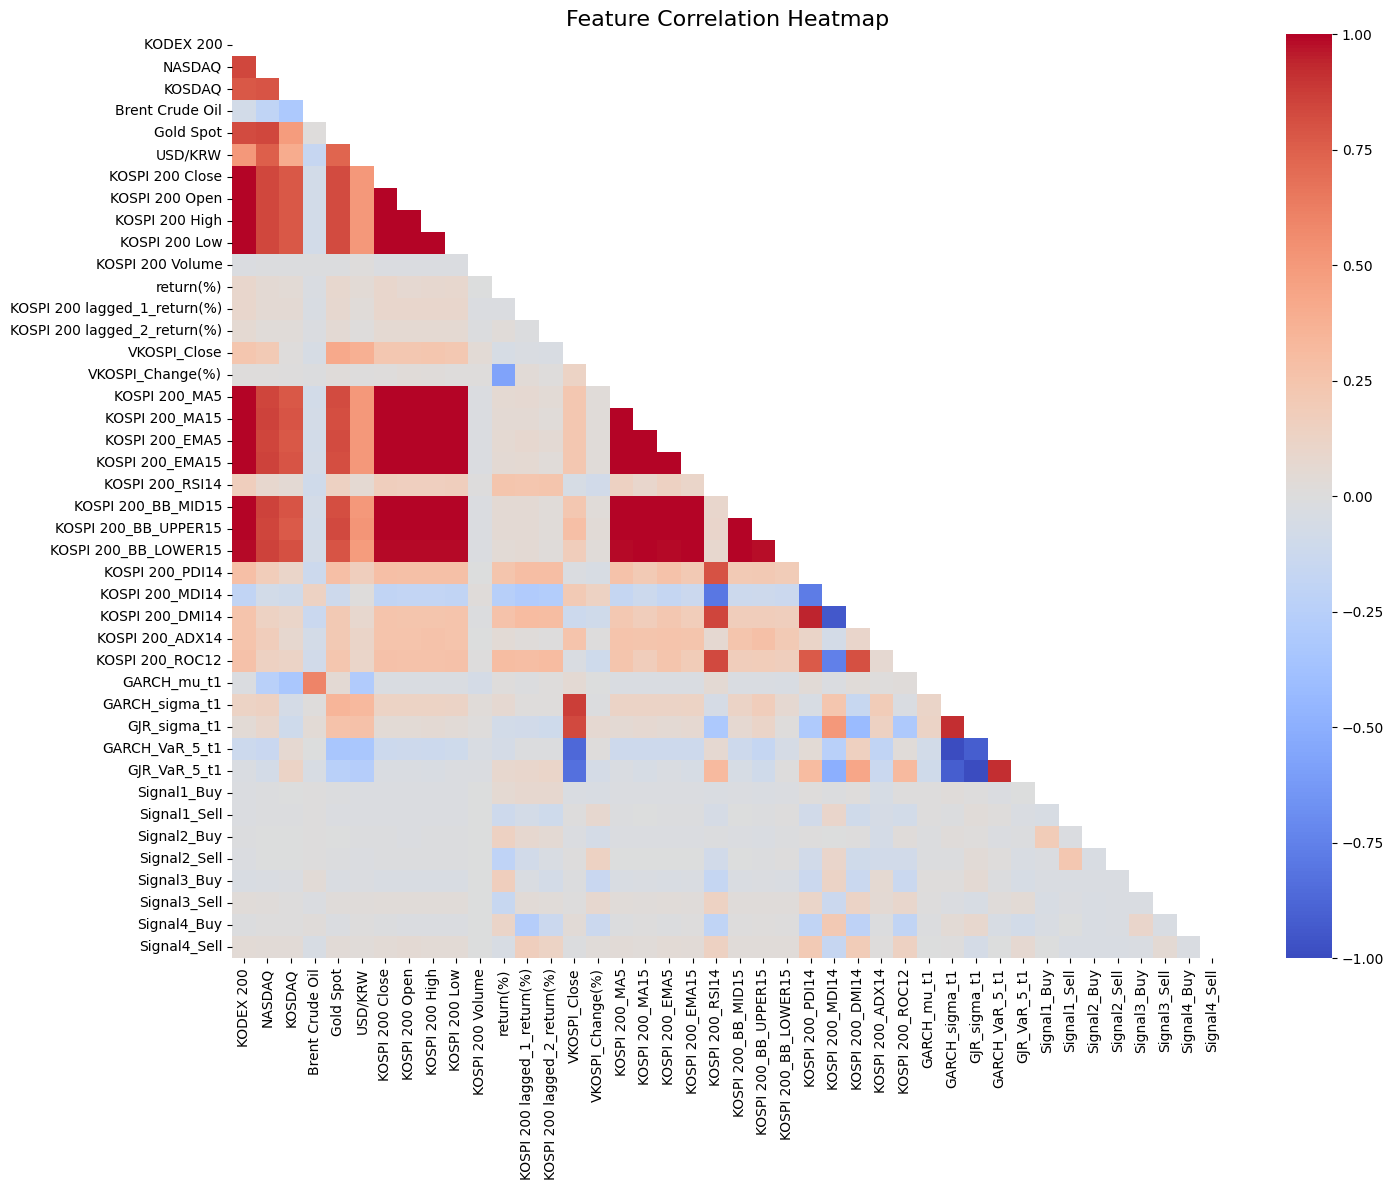

c:\Users\cj020\OneDrive\Labtop\KDISS\TS_RL_proj\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KOSPI 200_BB_LOWER15,inf
1,KOSPI 200_MA15,inf
2,KOSPI 200_BB_MID15,inf
3,KOSPI 200_BB_UPPER15,inf
4,KOSPI 200_DMI14,2251799813685248.0000
5,KOSPI 200_PDI14,195808679450891.1250
6,KOSPI 200_MDI14,136472715980924.1250
7,KOSPI 200_EMA5,93900.1195
8,KOSPI 200_MA5,30709.0079
9,GARCH_sigma_t1,25587.9726



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200_BB_LOWER15', 'KOSPI 200_MA15', 'KOSPI 200_BB_MID15', 'KOSPI 200_BB_UPPER15', 'KOSPI 200_DMI14', 'KOSPI 200_PDI14', 'KOSPI 200_MDI14', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'KODEX 200', 'NASDAQ', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [53]:
check_multicollinearity(full_data, target_col='Risk_Label')

### 볼린저 밴드 폭(BBwidth) 변수 생성 및 VIF 확인 (full_data_a)

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 40)



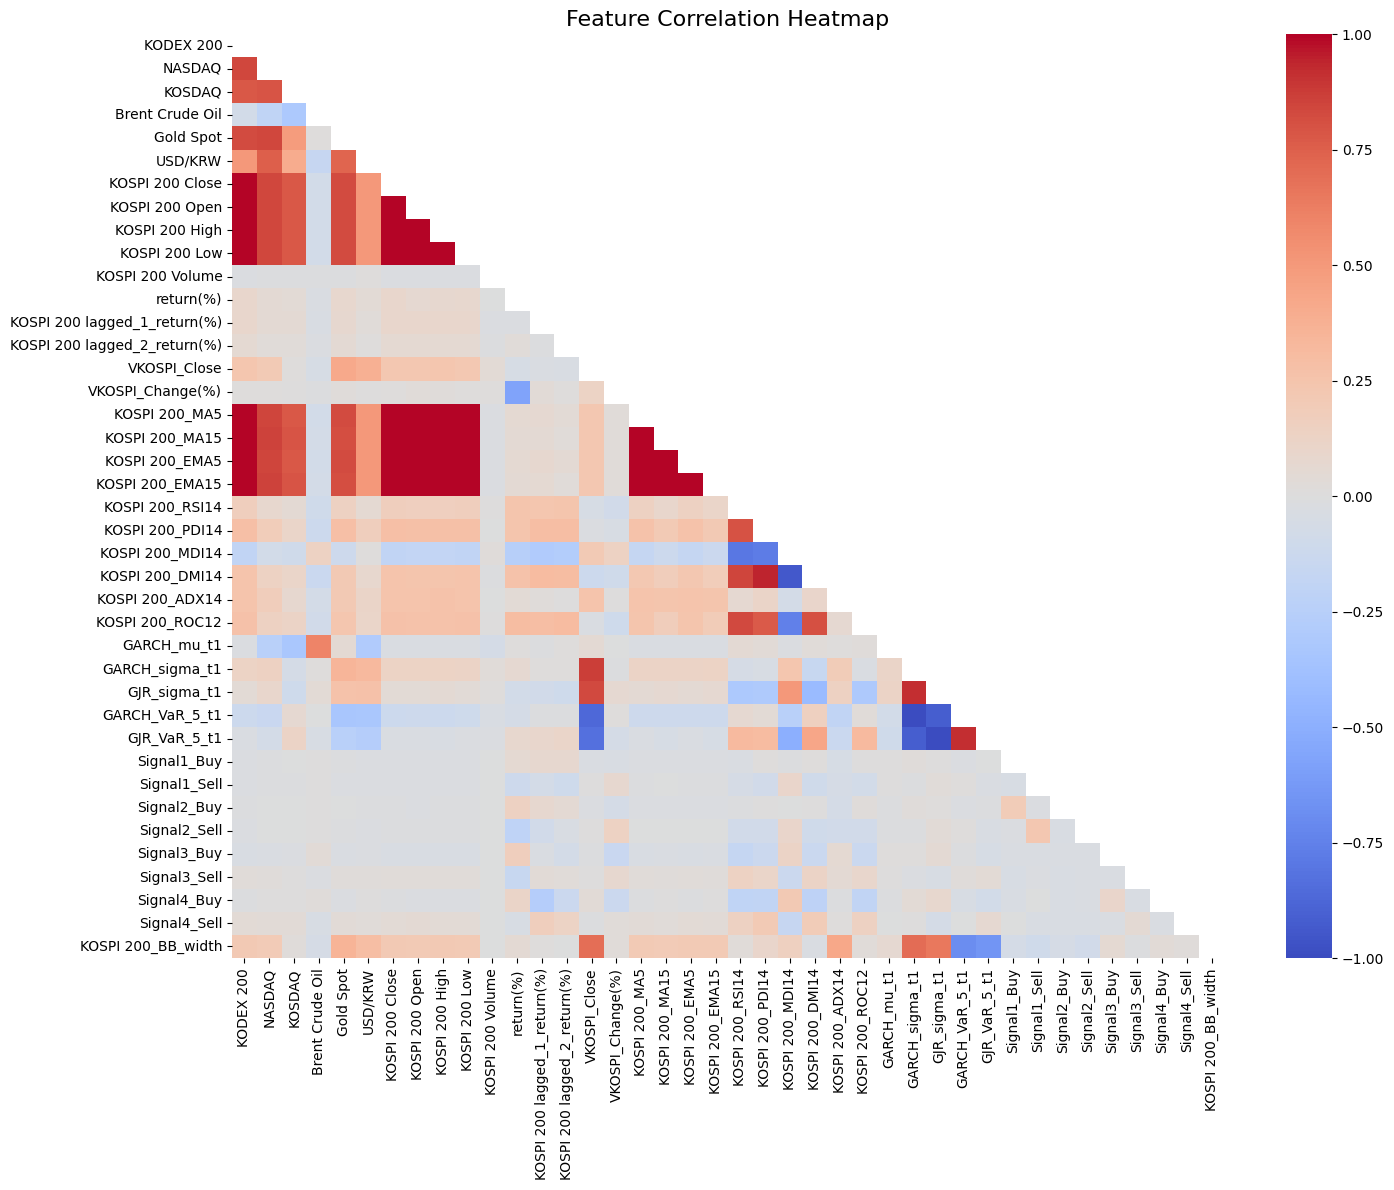


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KOSPI 200_MDI14,9007199254740992.0000
1,KOSPI 200_DMI14,1286742750677284.5000
2,KOSPI 200_PDI14,272945431961848.2500
3,KOSPI 200_EMA5,92772.1227
4,KOSPI 200_MA5,30517.2833
5,GARCH_sigma_t1,25614.8928
6,GARCH_VaR_5_t1,25391.3331
7,GJR_sigma_t1,18674.1010
8,GJR_VaR_5_t1,18533.8324
9,KOSPI 200 Close,15624.4299



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200_MDI14', 'KOSPI 200_DMI14', 'KOSPI 200_PDI14', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200_MA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'KODEX 200', 'NASDAQ', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [54]:
full_data_a = full_data.assign(
    **{'KOSPI 200_BB_width': 
       (full_data['KOSPI 200_BB_UPPER15'] - full_data['KOSPI 200_BB_LOWER15']) / full_data['KOSPI 200_BB_MID15']}).drop(columns=['KOSPI 200_BB_UPPER15','KOSPI 200_BB_LOWER15','KOSPI 200_BB_MID15'])

check_multicollinearity(full_data_a, target_col='Risk_Label')

## MDI, PDI 제거 후 VIF 확인 (full_data_b, DMI만 이용)

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 38)



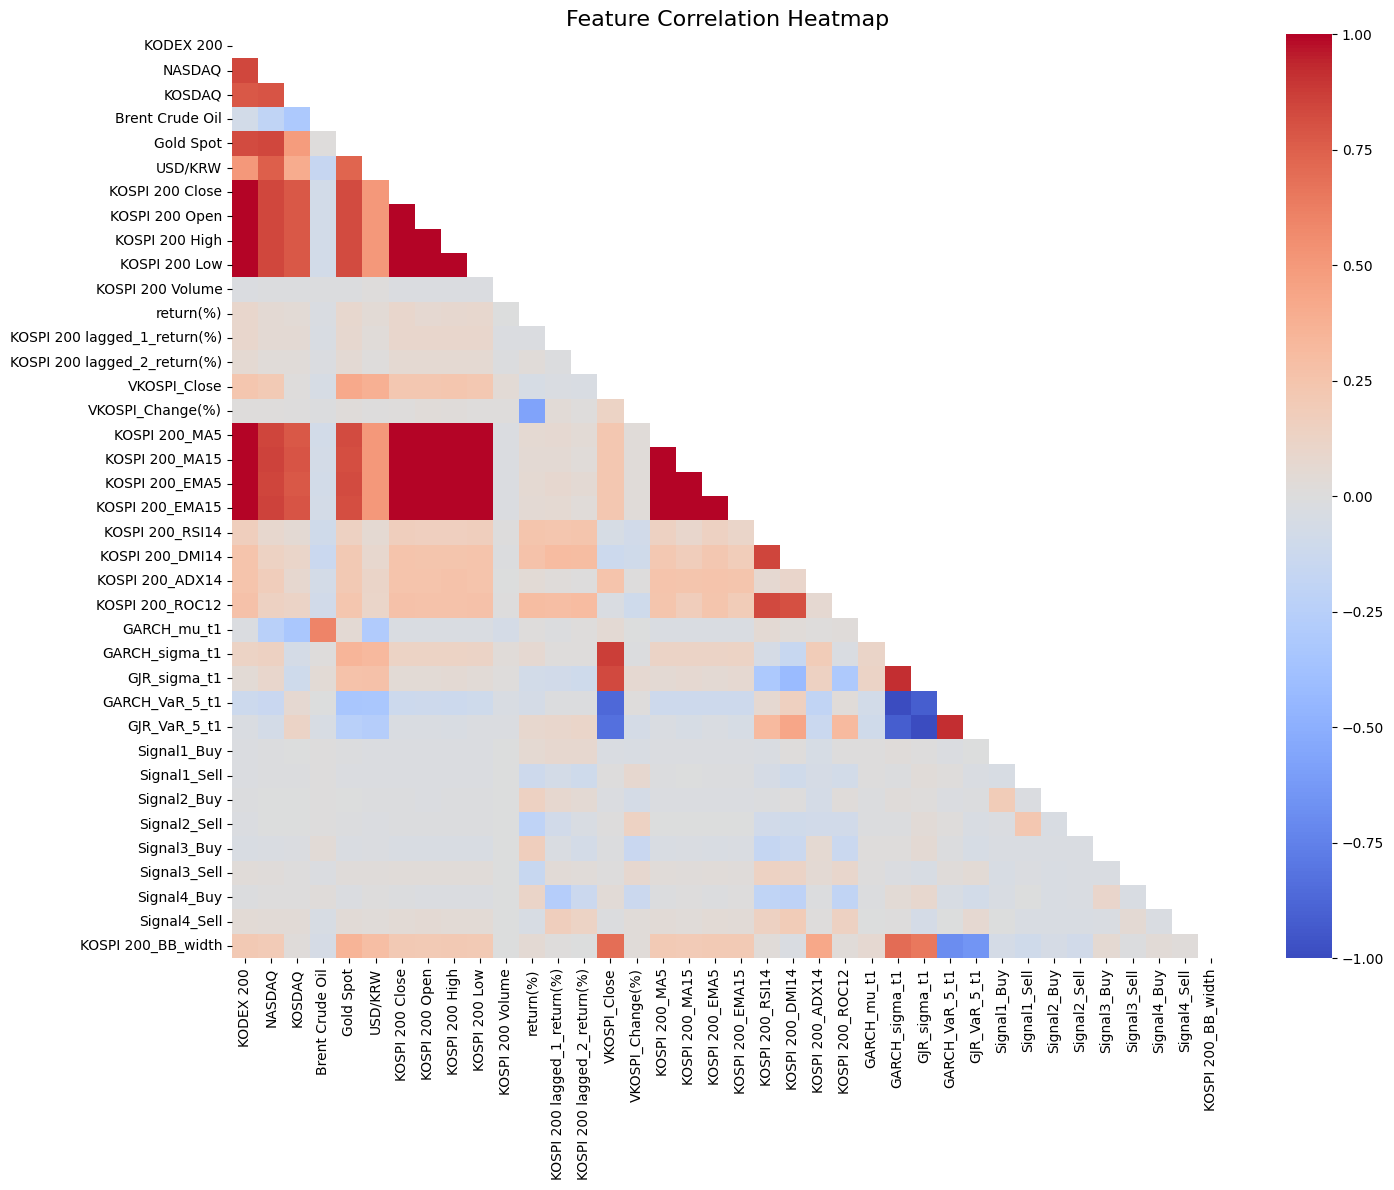


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KOSPI 200_EMA5,92668.7752
1,KOSPI 200_MA5,30500.5890
2,GARCH_sigma_t1,24827.8665
3,GARCH_VaR_5_t1,24612.6606
4,GJR_sigma_t1,18297.1058
5,GJR_VaR_5_t1,18171.2459
6,KOSPI 200 Close,15617.2148
7,KOSPI 200_EMA15,8781.7670
8,KOSPI 200_MA15,8366.2253
9,KOSPI 200 High,6542.8435



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200_EMA5', 'KOSPI 200_MA5', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200_MA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'KODEX 200', 'NASDAQ', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [55]:
# 1. full_data_a에서 MDI, PDI 제거 후 full_data_b에 대입
full_data_b = full_data_a.drop(columns=['KOSPI 200_MDI14', 'KOSPI 200_PDI14'], errors='ignore')

# 2. full_data_b로 VIF 함수 실행
check_multicollinearity(full_data_b, target_col='Risk_Label')

### EMA12/26 추가를 통한 MACD 계산, MA족 변수 모두 드랍 후 VIF 확인

KOSPI 200_PPO         0
KOSPI 200_PPO_Hist    0
dtype: int64
🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 36)



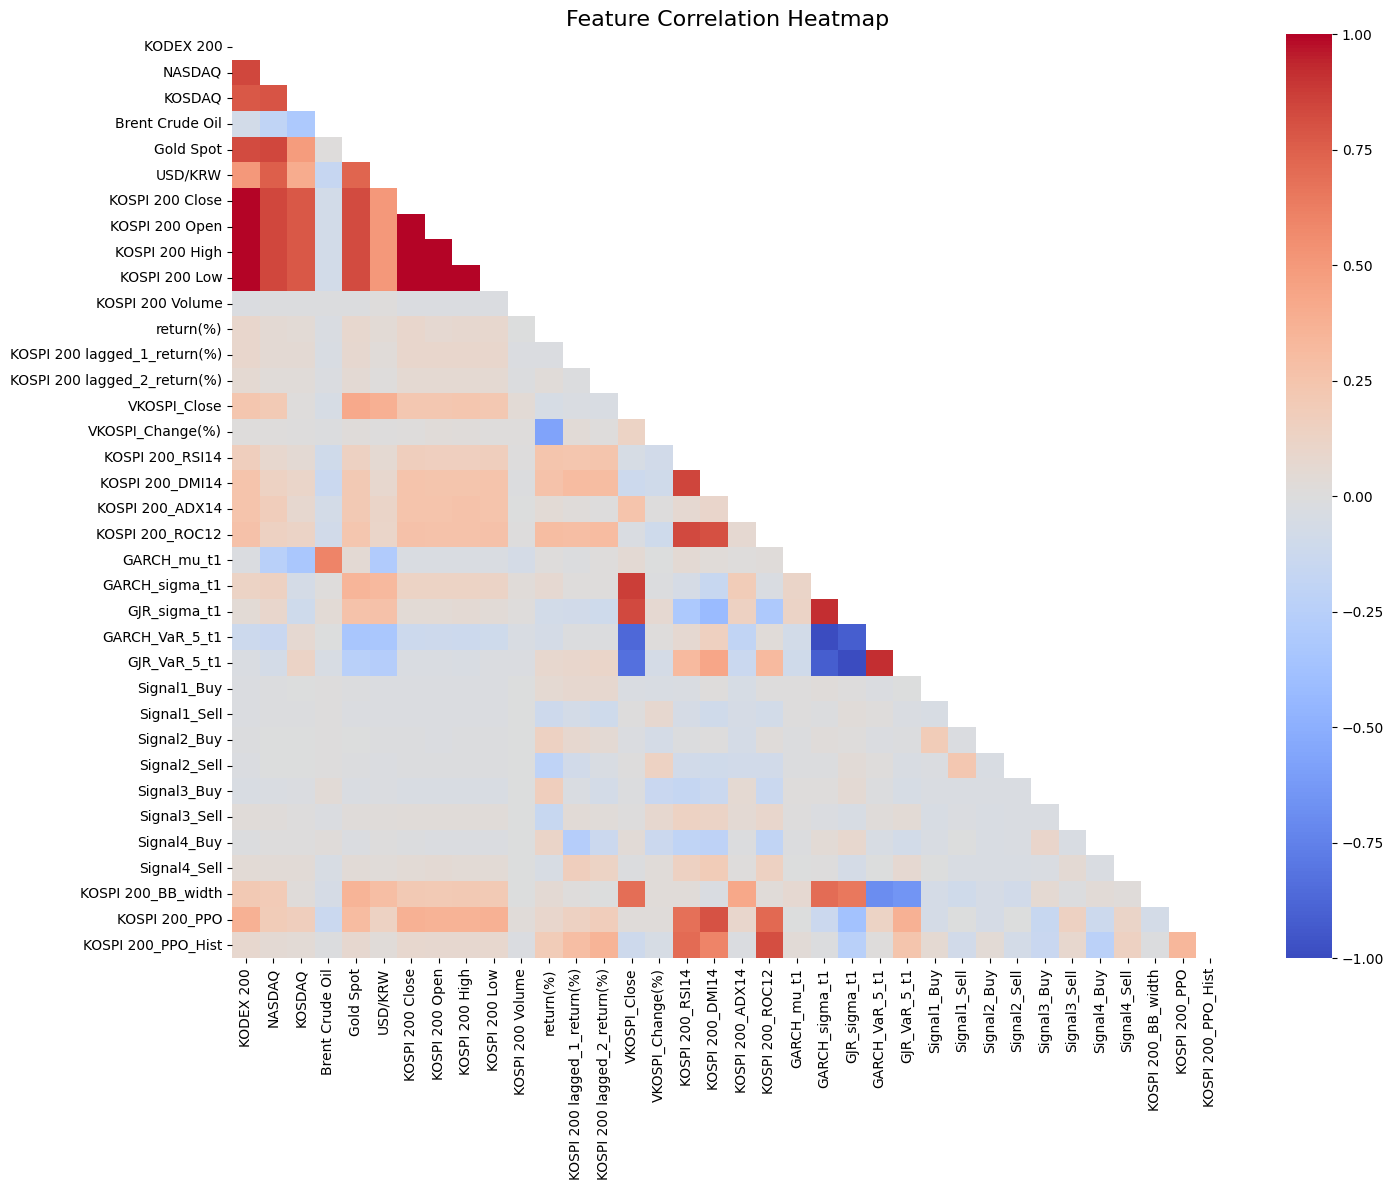


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,GARCH_sigma_t1,24599.3622
1,GARCH_VaR_5_t1,24392.5317
2,GJR_sigma_t1,18411.2550
3,GJR_VaR_5_t1,18277.9297
4,KOSPI 200 Close,7202.8608
5,KOSPI 200 High,6423.3229
6,KOSPI 200 Low,5013.1561
7,KOSPI 200 Open,4606.8616
8,KODEX 200,2105.8652
9,NASDAQ,24.2881



🚨 VIF 10 이상인 위험 변수 목록:
['GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'KODEX 200', 'NASDAQ', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [56]:
data_2008_test = pd.read_csv(r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

close = data_2008_test['KOSPI 200 Close']

ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()

# 1. PPO 계산 (PPO = (EMA12 - EMA26) / EMA26 * 100)
data_2008_test['KOSPI 200_PPO'] = (ema12 - ema26) / ema26 * 100

# 2. PPO 시그널 계산 (PPO의 9일 지수이동평균)
data_2008_test['KOSPI 200_PPO_Signal'] = (data_2008_test['KOSPI 200_PPO']
    .ewm(span=9, adjust=False).mean()
)

# 3. PPO 히스토그램 계산 (PPO - PPO 시그널)
data_2008_test['KOSPI 200_PPO_Hist'] = (data_2008_test['KOSPI 200_PPO']
    - data_2008_test['KOSPI 200_PPO_Signal']
)

# 4. full_data_b를 복사하여 full_data_c 생성 후 기존에 같은 컬럼이 있으면 제거
full_data_c = full_data_b.copy().sort_index()
full_data_c = full_data_c.drop(columns=[
    'KOSPI 200_PPO',
    'KOSPI 200_PPO_Hist'
], errors='ignore')

# 5. data_2008_test에서 필요한 컬럼(PPO, PPO_Hist)만 병합
full_data_c = full_data_c.join(
    data_2008_test[['KOSPI 200_PPO', 'KOSPI 200_PPO_Hist']],
    how='left'
)

# 6. 다중공선성의 원인이 되는 재료 변수들(이동 평균 족 변수) 일괄 삭제
full_data_c = full_data_c.drop(columns=[
    'KOSPI 200_MA5',
    'KOSPI 200_MA15',
    'KOSPI 200_EMA5',
    'KOSPI 200_EMA15'
], errors='ignore')

# 5.5 full_data_c의 변수별 결측치 확인
print(full_data_c[['KOSPI 200_PPO', 'KOSPI 200_PPO_Hist']].isna().sum())

# 6. 결과 확인 및 VIF 실행
check_multicollinearity(full_data_c, target_col='Risk_Label')

### GJR/GARCH VaR과 mu/sigma_t1은 선형종속 => sigma_t1 제거

['KODEX 200', 'NASDAQ', 'KOSDAQ', 'Brent Crude Oil', 'Gold Spot', 'USD/KRW', 'KOSPI 200 Close', 'KOSPI 200 Open', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Volume', 'return(%)', 'KOSPI 200 lagged_1_return(%)', 'KOSPI 200 lagged_2_return(%)', 'VKOSPI_Close', 'VKOSPI_Change(%)', 'KOSPI 200_RSI14', 'KOSPI 200_DMI14', 'KOSPI 200_ADX14', 'KOSPI 200_ROC12', 'GJR_VaR_5_t1', 'Signal1_Buy', 'Signal1_Sell', 'Signal2_Buy', 'Signal2_Sell', 'Signal3_Buy', 'Signal3_Sell', 'Signal4_Buy', 'Signal4_Sell', 'Risk_Label', 'KOSPI 200_BB_width', 'KOSPI 200_PPO', 'KOSPI 200_PPO_Hist']
🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 32)



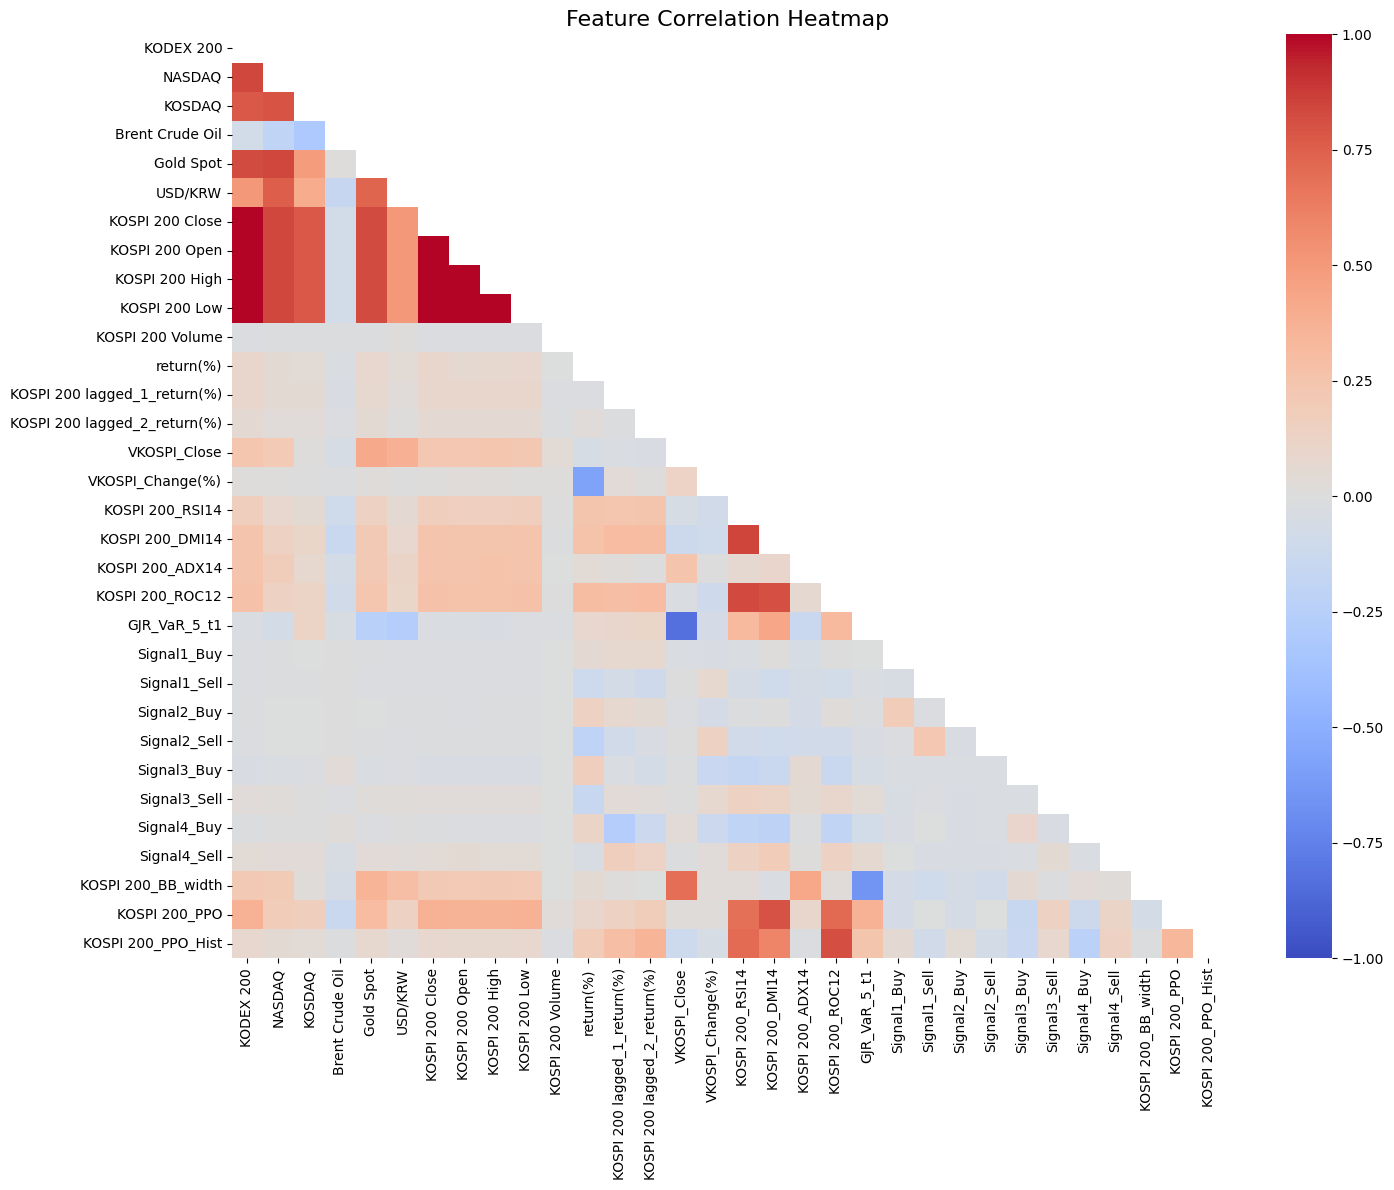


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KOSPI 200 Close,7135.5602
1,KOSPI 200 High,6364.4496
2,KOSPI 200 Low,4979.4987
3,KOSPI 200 Open,4602.5829
4,KODEX 200,2017.8381
5,NASDAQ,18.5252
6,Gold Spot,13.6935
7,KOSPI 200_ROC12,10.9217
8,KOSDAQ,9.1938
9,KOSPI 200_DMI14,8.4570



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200 Close', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'KODEX 200', 'NASDAQ', 'Gold Spot', 'KOSPI 200_ROC12']


In [57]:
full_data_d = full_data_c.copy().sort_index()

full_data_d = full_data_d.drop(columns=[
    "GARCH_sigma_t1",
    "GJR_sigma_t1",
    "GARCH_mu_t1",
    "GARCH_VaR_5_t1"
], errors="ignore")

# 제거 확인
print(full_data_d.columns.tolist())

# VIF 재확인
check_multicollinearity(full_data_d, target_col="Risk_Label")

### Open을 이용한 파생변수 Overnight Gap 생성 후, OHLC 제거

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 29)



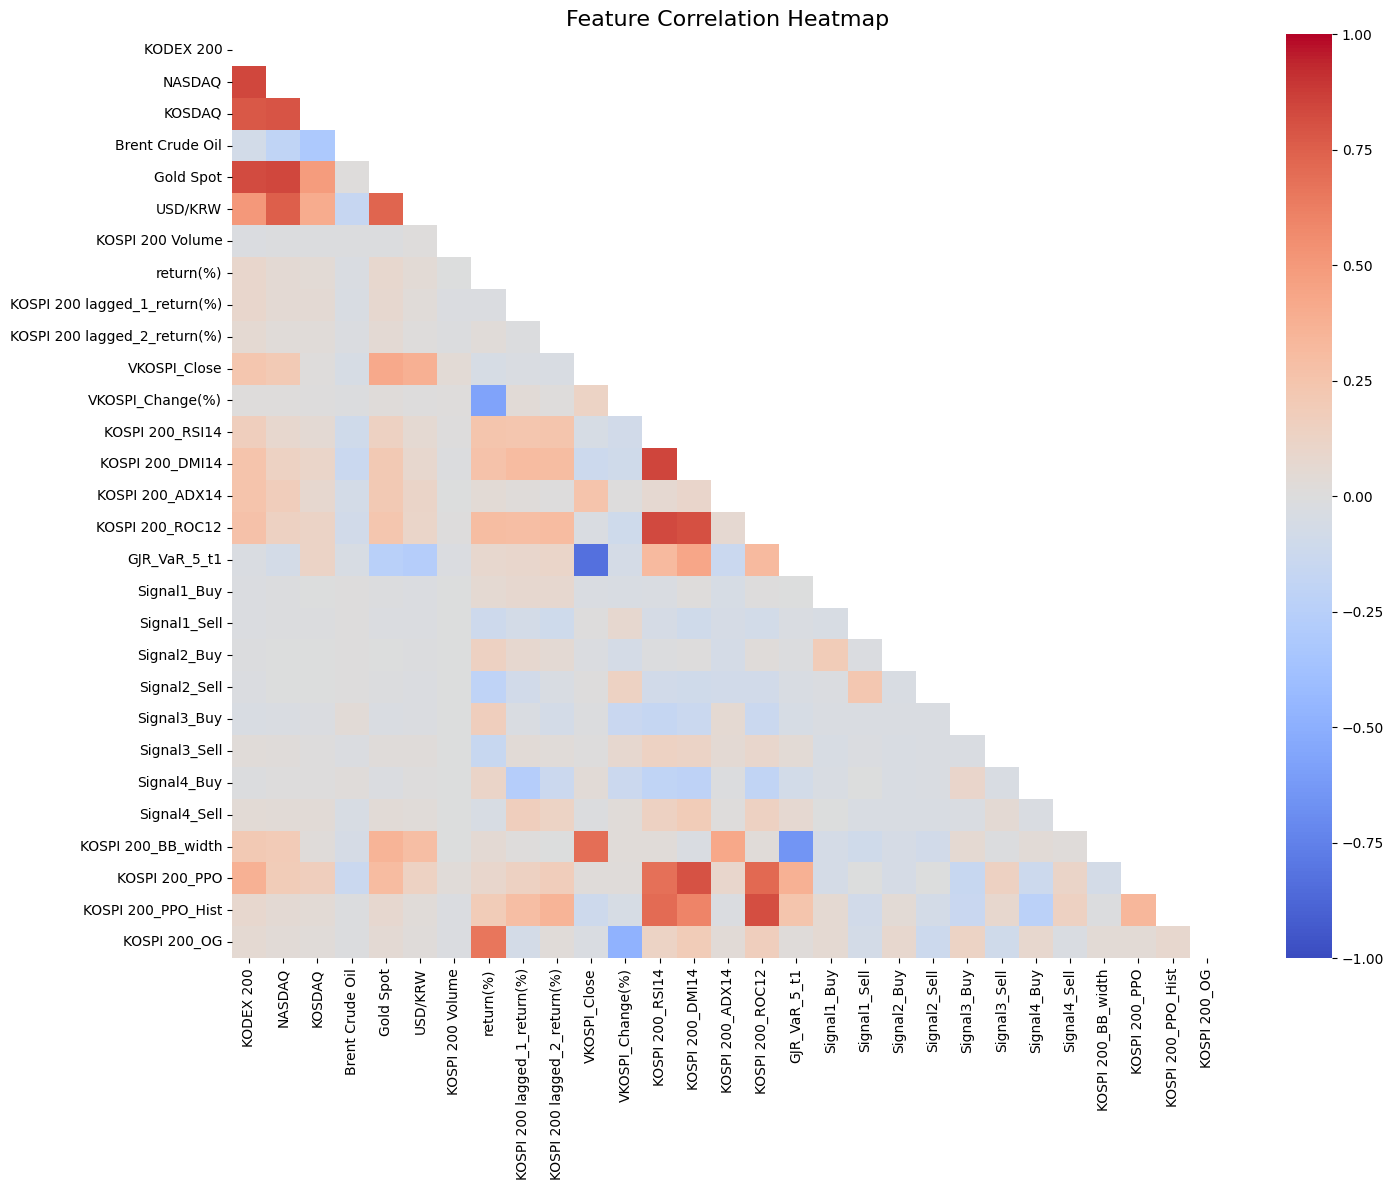


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,NASDAQ,18.3021
1,Gold Spot,13.5641
2,KODEX 200,11.7343
3,KOSPI 200_ROC12,10.8995
4,KOSDAQ,9.1610
5,KOSPI 200_DMI14,8.0593
6,KOSPI 200_PPO,7.6499
7,GJR_VaR_5_t1,7.3801
8,VKOSPI_Close,6.4786
9,KOSPI 200_PPO_Hist,6.1904



🚨 VIF 10 이상인 위험 변수 목록:
['NASDAQ', 'Gold Spot', 'KODEX 200', 'KOSPI 200_ROC12']


In [58]:
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

full_data_e = full_data_d.copy().sort_index()

# 기존 OG 컬럼이 있으면 제거
full_data_e = full_data_e.drop(columns=['KOSPI 200_OG'], errors='ignore')

# 1. 전일 종가
prev_close = data_2008_test['KOSPI 200 Close'].shift(1)

# 2. Overnight Gap 계산
data_2008_test['KOSPI 200_OG'] = (
    (data_2008_test['KOSPI 200 Open'] - prev_close)
    / prev_close
) * 100

# 3. 날짜 인덱스 기준 병합
full_data_e = full_data_e.join(
    data_2008_test[['KOSPI 200_OG']],
    how='left'
)

# 4. full_data_e의 OHLC 컬럼 제거
full_data_e = full_data_e.drop(
    columns=['KOSPI 200 Open', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Close'])

# VIF 확인
check_multicollinearity(full_data_e, target_col="Risk_Label")

### NASDAQ / Gold Spot의 로그 수익률화 및 ROC12 제거

결측치 확인:
NASDAQ_return(%)       0
Gold Spot_return(%)    0
dtype: int64
row count: 4108 -> 4108
🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 28)



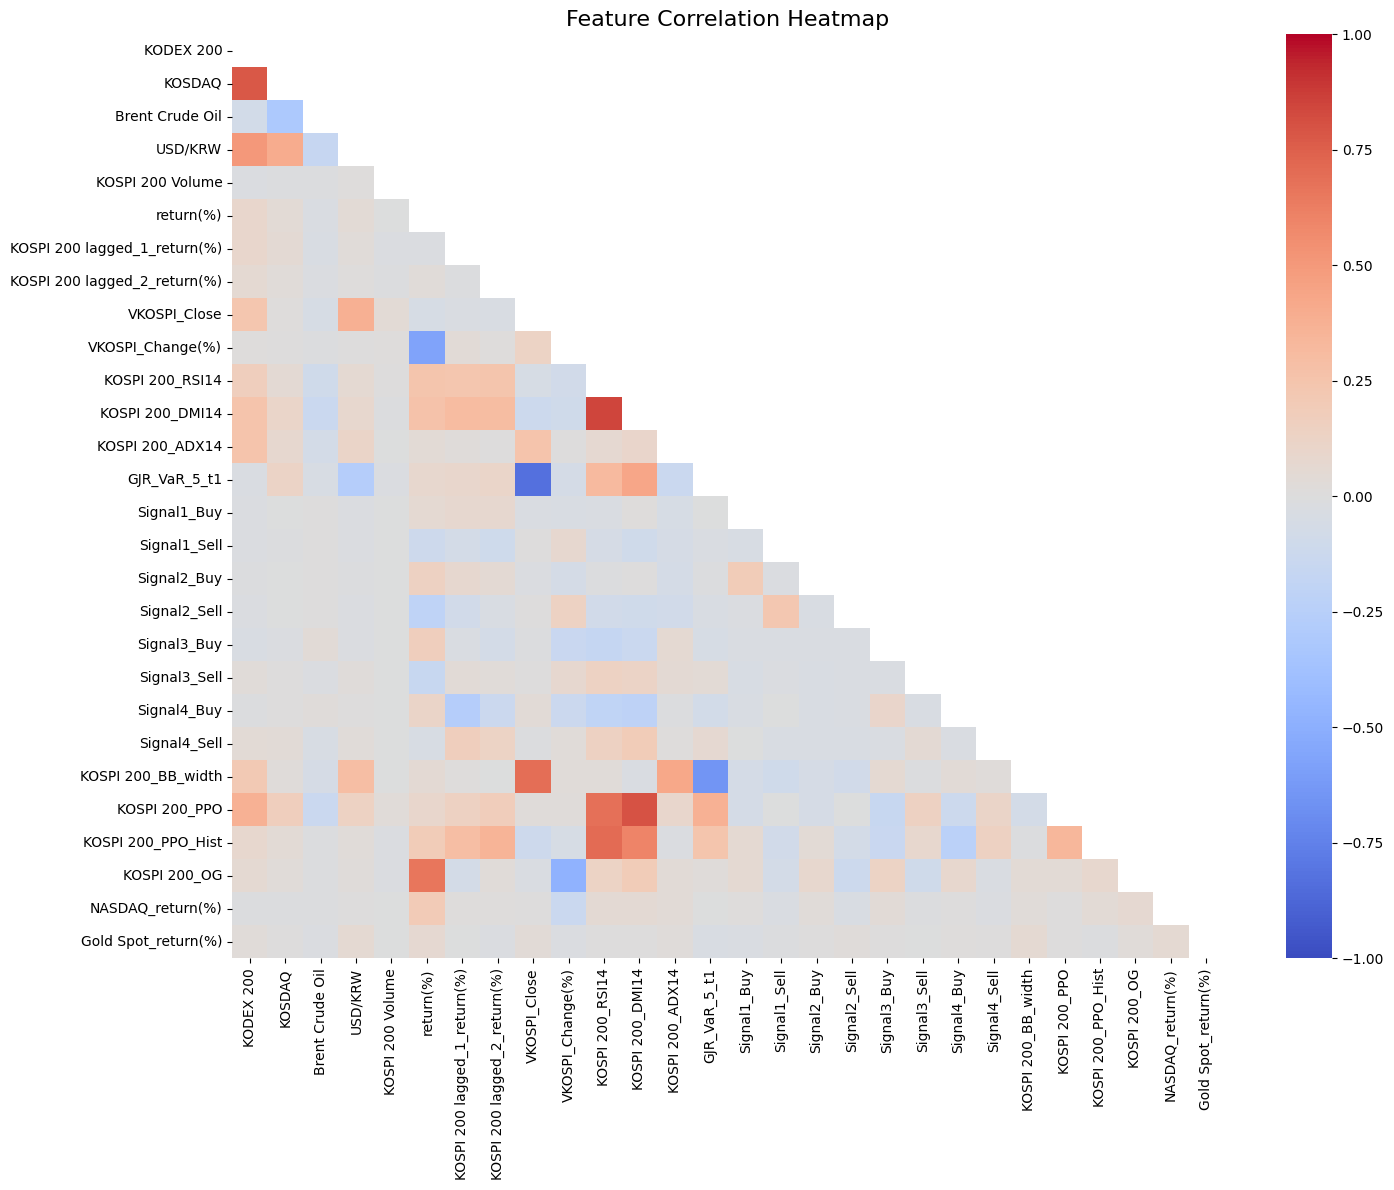


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KOSPI 200_DMI14,7.9524
1,GJR_VaR_5_t1,7.3259
2,VKOSPI_Close,6.3417
3,KOSPI 200_RSI14,5.2900
4,KOSPI 200_PPO,5.1060
5,KODEX 200,4.8873
6,KOSDAQ,4.1065
7,KOSPI 200_BB_width,2.7392
8,KOSPI 200_PPO_Hist,2.5787
9,return(%),2.5739



🚨 VIF 10 이상인 위험 변수 목록:
위험 수준의 변수가 없습니다. (모든 VIF 10 미만)


In [ ]:
# =========================
# 1. 2008년부터의 raw 데이터 불러오기
# =========================
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

# =========================
# 2. NASDAQ, Gold Spot 변화율 생성
#    log(P_t / P_{t-1}) * 100
# =========================
data_2008_test["NASDAQ_return(%)"] = (
    np.log(data_2008_test["NASDAQ"] / data_2008_test["NASDAQ"].shift(1)) * 100
)
data_2008_test["Gold Spot_return(%)"] = (
    np.log(data_2008_test["Gold Spot"] / data_2008_test["Gold Spot"].shift(1)) * 100
)

# =========================
# 3. 현재 분석 데이터 복사
# =========================
full_data_f = full_data_e.copy().sort_index()

# =========================
# 4. 기존 return 컬럼이 있으면 제거
# =========================
full_data_f = full_data_f.drop(columns=[
    "NASDAQ_return(%)",
    "Gold Spot_return(%)",
    "KOSPI 200_ROC12"
], errors="ignore")

# =========================
# 5. 날짜 인덱스 기준으로 변화율 변수 병합
# =========================
full_data_f = full_data_f.join(
    data_2008_test[["NASDAQ_return(%)", "Gold Spot_return(%)"]],
    how="left"
)

# =========================
# 6. 원 변수 제거
# =========================
full_data_f = full_data_f.drop(columns=[
    "NASDAQ",
    "Gold Spot"
], errors="ignore")

# =========================
# 7. 병합 결과 확인
# =========================
print("결측치 확인:")
print(full_data_f[["NASDAQ_return(%)", "Gold Spot_return(%)"]].isna().sum())
print("row count:", len(full_data_e), "->", len(full_data_f))

# =========================
# 8. VIF 확인
# =========================
check_multicollinearity(full_data_f, target_col="Risk_Label")


### 변수 재정렬

In [68]:
new_order = [
    'KODEX 200','KOSDAQ','NASDAQ_return(%)','Brent Crude Oil','Gold Spot_return(%)','USD/KRW',
    
    'KOSPI 200 Volume',

    'return(%)',
    'KOSPI 200 lagged_1_return(%)',
    'KOSPI 200 lagged_2_return(%)',

    'VKOSPI_Close',
    'VKOSPI_Change(%)',

    'KOSPI 200_RSI14',
    'KOSPI 200_DMI14',
    'KOSPI 200_ADX14',
    'KOSPI 200_BB_width',
    'KOSPI 200_PPO',
    'KOSPI 200_PPO_Hist',
    'KOSPI 200_OG',

    'GJR_VaR_5_t1',

    'Signal1_Buy',
    'Signal1_Sell',
    'Signal2_Buy',
    'Signal2_Sell',
    'Signal3_Buy',
    'Signal3_Sell',
    'Signal4_Buy',
    'Signal4_Sell',

    'Risk_Label'
]

# 혹시 누락/오타 체크
missing_cols = [col for col in new_order if col not in full_data_f.columns]
extra_cols = [col for col in full_data_f.columns if col not in new_order]

print("누락된 컬럼:", missing_cols)
print("추가 컬럼:", extra_cols)

# 재배치
data_vif = full_data_f[new_order]

# 데이터 저장
data_vif.to_csv("../../data/processed/data_vif.csv", index=True)

누락된 컬럼: []
추가 컬럼: []
